In [1]:
import jax
import jax.numpy as jnp
import roughpy_jax as rpj
from RoughKernel.utils import uniform_intervals, make_LIS, perturb_streams
from RoughKernel.solver import RoughKernel
import sklearn
import matplotlib.pyplot as plt 

# Outline

The contents of this notebook give a demonstration of the application of the **Rough Signature Kernel**, where we use it to find messages inserted into Brownian stream data. 

The Rough Signature Kernel was introduced in the paper [Log-PDE Methods for Rough Signature Kernels](https://arxiv.org/pdf/2404.02926), of particular importance is algorithm 5.1 which provides a numerical framework for the kernel. In the `solver.py` file contained within this repo is the first numerical implementation of this kernel in JAX. It relies heavily on RoughPy-JAX to provide the signature and tensor/Lie algebra framework.

`Brownian_streams_100.npy` contains 100 4-dimensional Brownian streams stored as increments and in the free Lie algebra with depth 2. We will insert a message into some of these streams, and use SVM with the Rough Signature Kernel to classify which streams received which message.

In [ ]:
streams = jnp.load("Brownian_streams_100.npy")

N_streams = 100
W = 4
n = 2
R = 10 # R and L can be considered hyper-parameters, higher value = better result, but higher cost
L = 20

Lie_Basis = rpj.LieBasis(width = W, depth = n)
streams.shape # (100, 2048, 10): 100 streams, 2048 increments, in the Free Lie algebra of width 4 depth 2

(100, 2048, 10)

# Building a Message

Things to consider:

* **How many streams** to perturb?
* **How many increments** in each stream to perturb?
* **Which increments** to perturb, and how sparse these perturbations should be?
* **Given an increment, which layers** of the increment should be perturbed?
* **How large** the message should be?

In the below code we opt for two fairly simple messages. 

Message A will change the first order information (first layer) of the (sparse and random) increments it effects. It will be a constant size of 0.05, enough to be distinguishable from noise, but not too much to make it easy!

Message B will be very similar, but only change second order information (second layer), of the **same** increments. 

These messages will then be applied to distinct streams, so there are **not** any streams that have had both messages applied.

There are many different interesting ways of constructing messages, and it is not tricky to do so - essentially it is an exercise in indexing jnp arrays.



In [3]:
# build and apply message here

N_streams_perturbed = 20
N_rows_perturbed = 50

key = jax.random.PRNGKey(0)

A_stream_idx = jnp.arange(N_streams_perturbed) # this is fairly arbitrary, so we pick first 20
# for the increments to perturb, we don't want them too clustered (as that is easier to see)
A_inc_idx = jax.random.choice(key, 2048, shape=(N_rows_perturbed,), replace=False)

# message_A we want to perturb only the first order information, so we pad it with zeroes
first_order = jnp.ones((N_streams_perturbed, N_rows_perturbed, 4), dtype=jnp.float32) * 5e-2
message_A = jnp.concatenate([first_order, 
                             jnp.zeros((N_streams_perturbed, N_rows_perturbed, 6), dtype=jnp.float32)],
                             axis=-1)

# message B we choose to hit different streams, but the same increments (which should make it trickier)

B_stream_idx = A_stream_idx + N_streams_perturbed # making sure there is no overlap
B_inc_idx = A_inc_idx

# message B we want to perturb only the second order information
second_order = jnp.ones((N_streams_perturbed, N_rows_perturbed, 6), dtype=jnp.float32) * 5e-2
message_B = jnp.concatenate([jnp.zeros((N_streams_perturbed, N_rows_perturbed, 4), dtype=jnp.float32),
                             second_order],
                             axis=-1)

partial = perturb_streams(streams, message_A, Lie_Basis, A_stream_idx, A_inc_idx)
perturbed_streams = perturb_streams(partial, message_B, Lie_Basis, B_stream_idx, B_inc_idx)

In [4]:
# setting up the classification experiment

y = ['N' for _ in range(N_streams)] # 'N' stands for No Message
for i in A_stream_idx:
    y[i] = 'A'
for j in B_stream_idx:
    y[j] = 'B'

# train-test split

stream_train, stream_test, y_train, y_test = sklearn.model_selection.train_test_split(
    perturbed_streams, y, test_size = 0.2, stratify = y, random_state = 42
)

# The Rough Signature Kernel

- The **signature** of a path $\mathbf{x}:[0, 1] \rightarrow \mathbb{R}^d$, $S(\mathbf{x})$, is a collection of iterated integrals that encodes the **shape and traversal of the path**, It completely characterises the path up to natural equivalences.
- It provides a representation of a path as an infinite-dimensional sequence of iterated integrals, most easily treated as an element of the Free Tensor Algebra:
  $$S(\mathbf{x})_{a, b} = \left(1, \int_{a<t_1<b} d\mathbf{x_{t_1}}, \int_{a<t_2<t_2<b} d\mathbf{x_{t_1}\otimes x_{t_2}},  ...\right). $$
- The **signature kernel** compares two paths by taking the inner product of their signatures:
  $$ K(X,Y)=\langle S(X),S(Y)\rangle.$$
- Rather than explicitly computing these signatures, for smooth paths the kernel can be computed directly via a PDE as in [this](https://arxiv.org/pdf/2006.14794) paper.

- The **rough signature kernel** extends this approach to paths with highly irregular or oscillatory behaviour, using higher-order local information to represent each interval.
- This can capture fine-scale path behaviour without requiring an extremely fine time discretisation which can lead to improved efficiency for long/oscillatory time series, and an increased sensitivity to perturbations in higher orders of the input data.

The above outline suppresses many of the techinical details, but a more complete introduction to signatures can be found [here](https://link.springer.com/book/10.1007/978-3-031-97239-3), or [here](https://arxiv.org/pdf/2404.06583). A reader interested in understanding the Rough Signature Kernel in more detail should refer to the [original paper](https://arxiv.org/pdf/2404.02926) for the full background on theory.

This implementation of the Rough Signature Kernel requires the data to be in the form of a [RoughPy-JAX](https://github.com/datasig-ac-uk/roughpy-jax) LieIncrementStream object. A LieIncrementStream object takes the log-signature over $2^R$ contiguous dyadic intervals of size $2^{-R}$. It also stores, the value of the log-signature for every larger dyadic interval. i.e. if R = 2, then the LIS will store the values of log-signatures over [0, 1/4],...,[3/4, 1] as well as [0, 1/2], [1/2, 1] and [0, 1]. This allows for much faster computation. For more on this see [here](https://proceedings.scipy.org/articles/DXWY3560#free-tensors-shuffle-tensors-and-lie-objects).

In [11]:
# need to transform the Brownian streams into a RoughPy-JAX LieIncrementStream object
# for this we need times 

single_times_train = jnp.arange(stream_train.shape[1])/stream_train.shape[1]
times_train = jnp.tile(single_times_train, (stream_train.shape[0], 1))

single_times_test = jnp.arange(stream_test.shape[1])/stream_test.shape[1]
times_test = jnp.tile(single_times_test, (stream_test.shape[0], 1))

train_LIS = make_LIS(times_train, stream_train, n=n, W=W, R=R, incremental=True, input_basis=Lie_Basis)
test_LIS = make_LIS(times_test, stream_test, n=n, W=W, R=R, incremental=True, input_basis=Lie_Basis)

In [12]:
# rough signature kernel with SVM here

intervals = uniform_intervals(L)

rk = RoughKernel(n=n)
K_train = rk.solve_PDE(intervals, train_LIS, train_LIS)

In [13]:
K_test = rk.solve_PDE(intervals, test_LIS, train_LIS) 

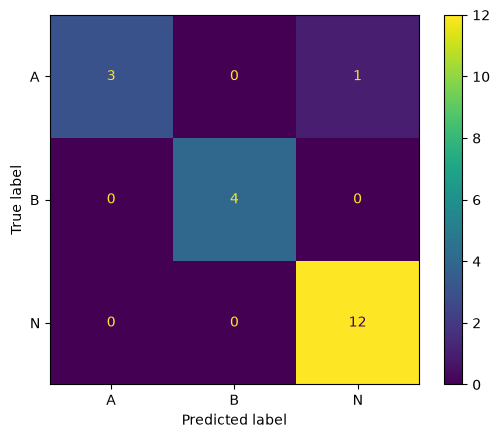

In [14]:
SVC = sklearn.svm.SVC(kernel='precomputed')
SVC.fit(K_train, y_train)
y_pred = SVC.predict(K_test)
conf_mat = sklearn.metrics.confusion_matrix(y_true=y_test, y_pred=y_pred)
display = sklearn.metrics.ConfusionMatrixDisplay(conf_mat, display_labels=('A', 'B', 'N'))
display.plot()
plt.show()